### Dataset 65
#### Johanna Tilešová - 50%
#### Adam Pečenka - 50%

# Fáza 3 - Strojové učenie: 20 bodov
Pri dátovej analýze nemusí byť naším cieľom získať len znalosti obsiahnuté v aktuálnych dátach, ale aj natrénovať model, ktorý bude schopný robiť rozumné predikcie pre nové pozorovania pomocou techniky strojového učenia. 

## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach  (5b)
- (A-2b) Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň). 
- (B-1b) Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.
- (C-2b) Zístite či Váš ID3 klasifikátor má overfit. Ak áno, riešte aby nemal overfitting.

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia (5b)
- (A-1b) Na trénovanie využite jeden stromový algoritmus v scikit-learn.
- (B-1b) Porovnajte s jedným iným nestromovým algoritmom v scikit-learn.
- (C-1b) Porovnajte výsledky s ID3 z prvého kroku.
- (D-1b) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus
- (E-1b) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

## 3.3 Optimalizácia alias hyperparameter tuning (5b)
- (A-1b) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).
- (B-1b) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu). 
- (C-1b) Využite krížovú validáciu (cross validation) na trénovacej množine.
- (D-2b) Dokážte že Váš nastavený najlepší model je bez overfitingu.

## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu (5b) 
Vyhodnoťte Vami zvolené stratégie riešenia projektu z hľadiska classification accuracy, či sú učinné pre Váš dataset: 
- (A-1b) Stratégie riešenia v data preprocessingu s daným datasetom.
- (B-1b) Dátová transformácia (scaling, transformer, …)
- (C-1b) Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning
- (D-1b) Ktorý model je Váš najlepší model pre nasadenie (deployment)? 
- (E-1b) Aký je data pipeline pre jeho vybudovanie na základe Vášho datasetu v produkcii?

Všetky hodnotenia podložte dôkazmi. Najlepší model má byť stabilný, bez overfitu a bez underfitu. Jeho data pipeline má byť dodaný s metadátami, ak tie metadáta sú potrebné a vyrobené v developmente.

In [33]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib

# Sklearn - predspracovanie a pipeline
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    PowerTransformer,
    QuantileTransformer
)

from sklearn.preprocessing import MinMaxScaler, RobustScaler

from sklearn.pipeline import Pipeline

# Sklearn - modely
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier

# Sklearn - metriky a vizualizácia
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import os
from sklearn.tree import export_graphviz
import graphviz

In [34]:
# Nastavenie vizualizácie
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42

In [35]:
mpl.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(palette="vanimo")

In [36]:
os.makedirs("pickles_ph3", exist_ok=True)

## Opravenie Pipeline z fázy 2

In [37]:
def histogramiada(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns
    n_cols = len(numeric_cols)

    if n_cols == 0:
        print("[!] No numeric columns to plot.")
        return

    per_page = 9
    n_pages = int(np.ceil(n_cols / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = start + per_page
        cols_subset = numeric_cols[start:end]

        fig, axes = plt.subplots(3, 3, figsize=(12, 10))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            sns.histplot(df[col], bins=bins, kde=True, ax=axes[i],
                         color=sns.color_palette("tab10")[i % 10])
            axes[i].set_title(col, fontsize=11)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        # hide unused subplots if fewer than 9
        for j in range(len(cols_subset), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Top features {start + 1}–{min(end, n_cols)}", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

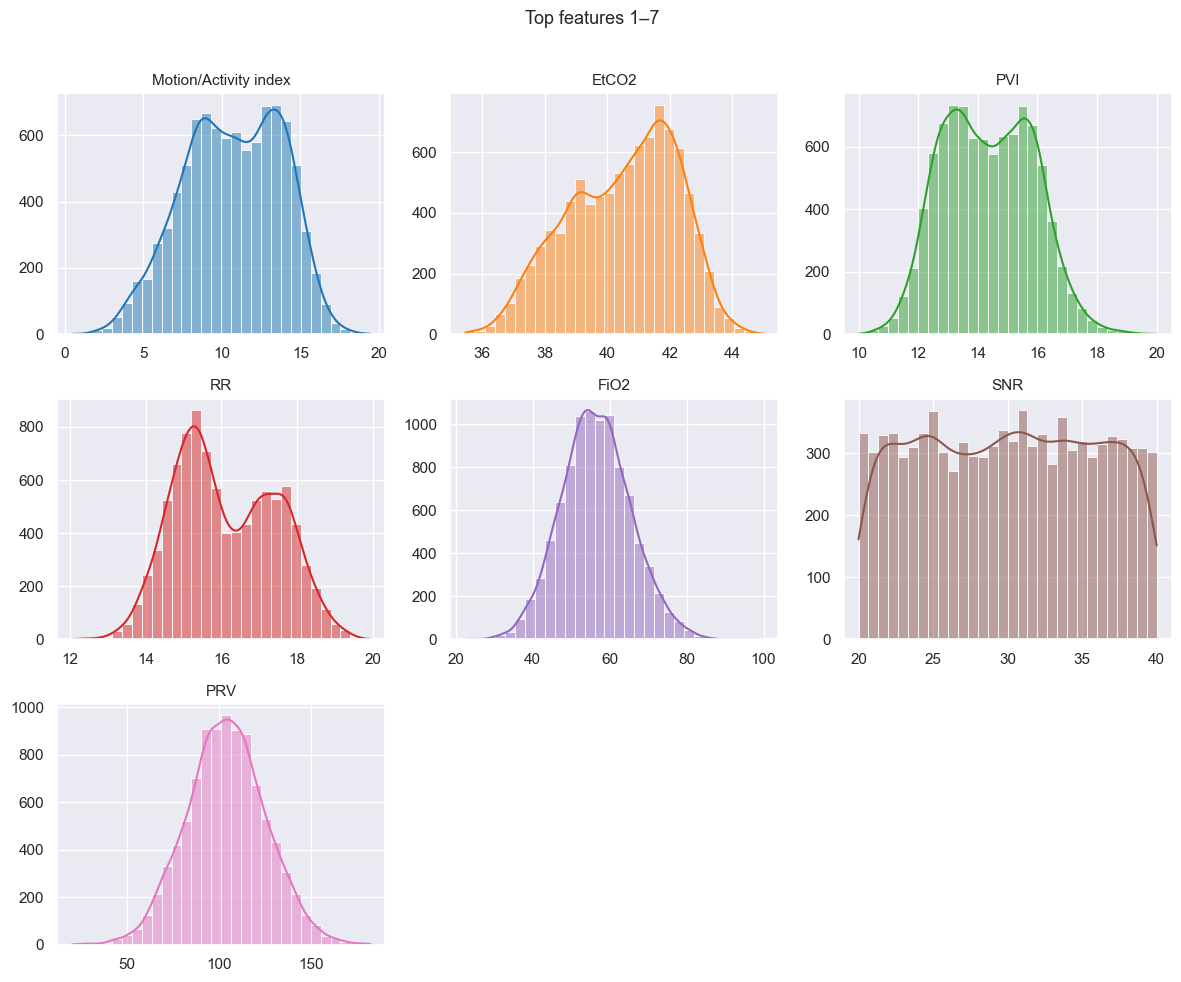

['pickles_ph3/preprocessing_pipeline_3_4.pkl']

In [85]:
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')

df_observation.rename(
    columns={
        "SpO₂": "SpO2",
        "EtCO₂": "EtCO2",
        "FiO₂": "FiO2",
        "O₂ extraction ratio": "O2 extraction ratio"
    },
    inplace=True
)

# vieme z fazy 2
selected_features = ["Motion/Activity index", "EtCO2", "PVI", "RR", "FiO2", "SNR", "PRV", "oximetry"]

df = df_observation[selected_features]

df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=['oximetry'])
y = df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

histogramiada(X_train)

pipeline = Pipeline(
    steps=[
        ('quantile_transformer', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('robust_scaler', RobustScaler())
    ]
)

pipeline_3_4 = Pipeline(
    steps=[
        ('poover_transformer', PowerTransformer(method='yeo-johnson')),
        ('minmax_scaler', MinMaxScaler())
    ]
)

pipeline.fit(X_train)
pipeline_3_4.fit(X_train)

X_train_processed = pipeline.transform(X_train)
X_test_processed  = pipeline.transform(X_test)

X_train_processed_3_4 = pipeline_3_4.transform(X_train)
X_test_processed_3_4  = pipeline_3_4.transform(X_test)

X_train_df = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=X_test.columns,  index=X_test.index)

train_final = pd.concat([X_train_df, y_train], axis=1)
test_final  = pd.concat([X_test_df,  y_test],  axis=1)

train_final.to_csv("processed_train.csv", index=False)
test_final.to_csv("processed_test.csv", index=False)

joblib.dump(pipeline, "pickles_ph3/preprocessing_pipeline.pkl")
joblib.dump(pipeline, "pickles_ph3/preprocessing_pipeline_3_4.pkl")

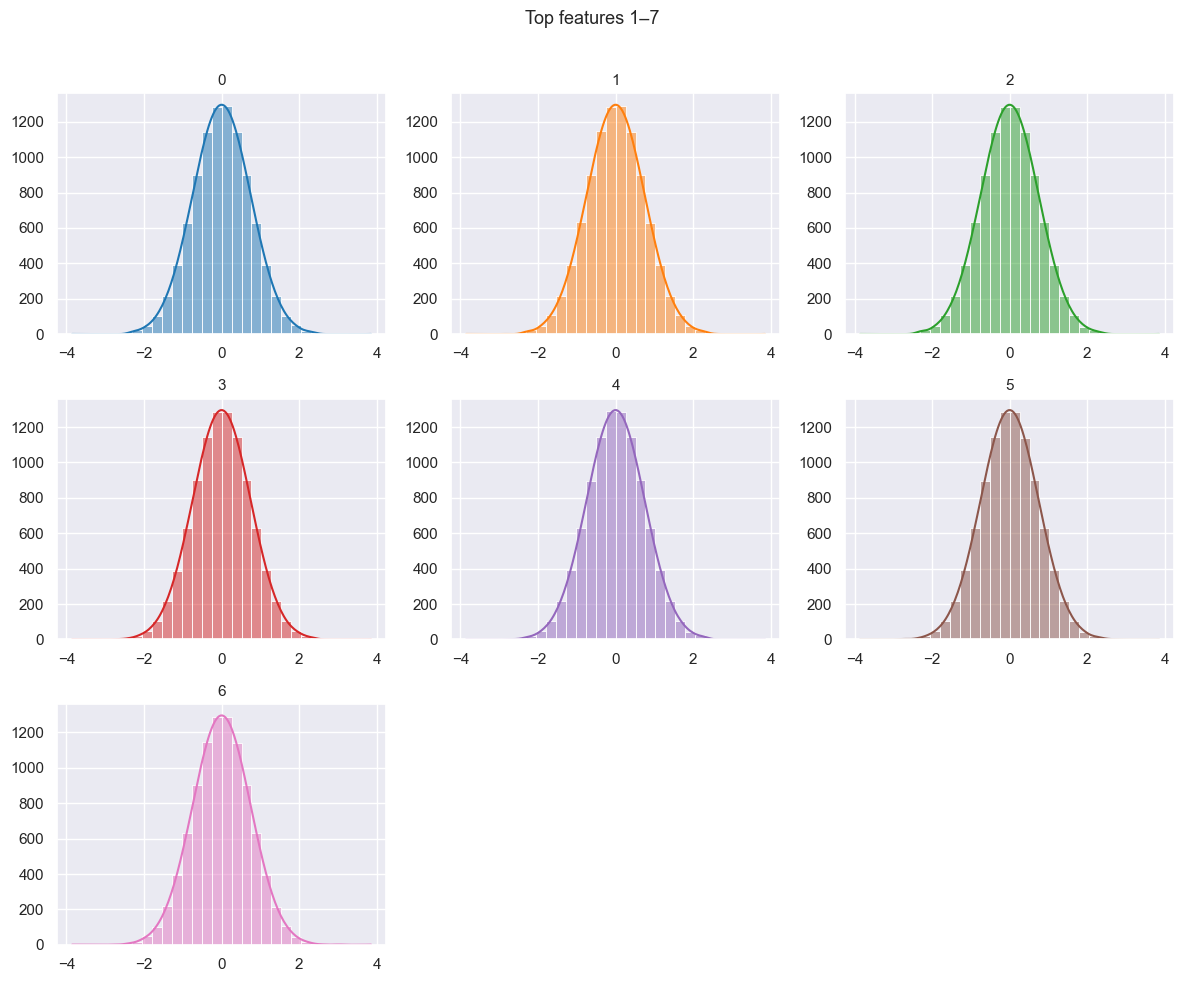

In [39]:
histogramiada(pd.DataFrame(X_train_processed))

# 3.1 Jednoduchý klasifikátor na základe závislosti v dátach

### 3.1A Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň).

In [40]:
class ID3Classifier:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities))

    def information_gain(self, X_column, y, threshold):
        parent_entropy = self.entropy(y)

        left_mask = X_column <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0

        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        e_left = self.entropy(y[left_mask])
        e_right = self.entropy(y[right_mask])
        child_entropy = (n_left / n) * e_left + (n_right / n) * e_right

        return parent_entropy - child_entropy

    def find_best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                gain = self.information_gain(X_column, y, threshold)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_labels == 1 or \
           n_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        best_feature, best_threshold, best_gain = self.find_best_split(X, y)

        if best_gain == 0:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
        return self

    def predict_sample(self, x, tree):
        if tree['leaf']:
            return tree['value']

        if x[tree['feature']] <= tree['threshold']:
            return self.predict_sample(x, tree['left'])
        else:
            return self.predict_sample(x, tree['right'])

    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)


In [41]:
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

clf = ID3Classifier(max_depth=2)
clf.fit(X_train_np, y_train_np)

y_pred_train = clf.predict(X_train_np)
y_pred_test = clf.predict(X_test_np)

train_accuracy = accuracy_score(y_train_np, y_pred_train)
test_accuracy = accuracy_score(y_test_np, y_pred_test)

accuracy_diff = abs(test_accuracy - train_accuracy)
is_overfitting = accuracy_diff >= 0.1

id3_results = {
    "Model": "ID3 Custom Classifier",
    "Accuracy": accuracy_score(y_test_np, y_pred_test),
    "Precision": precision_score(y_test_np, y_pred_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_np, y_pred_test, average="weighted", zero_division=0)
}

print("=" * 60)
print("TRAINING SET RESULTS")
print("=" * 60)
print(f"Accuracy: {train_accuracy:.4f}\n")
print(classification_report(y_train_np, y_pred_train))

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test_np, y_pred_test))

print("=" * 60)
print("OVERFITTING EVALUATION")
print("=" * 60)
print(f"Accuracy Difference: {accuracy_diff:.4f}")
print(f"Overfitting Threshold: 0.1000")

if is_overfitting:
    print("[!] Model is OVERFITTING!")
else:
    print("[+] Model is NOT overfitting")

TRAINING SET RESULTS
Accuracy: 0.8074

              precision    recall  f1-score   support

         0.0       0.70      0.93      0.80      3851
         1.0       0.94      0.73      0.82      5644

    accuracy                           0.81      9495
   macro avg       0.82      0.83      0.81      9495
weighted avg       0.84      0.81      0.81      9495

TEST SET RESULTS
Accuracy: 0.8184

              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80       952
         1.0       0.94      0.75      0.83      1422

    accuracy                           0.82      2374
   macro avg       0.82      0.84      0.82      2374
weighted avg       0.85      0.82      0.82      2374

OVERFITTING EVALUATION
Accuracy Difference: 0.0111
Overfitting Threshold: 0.1000
[+] Model is NOT overfitting


In [42]:
print(id3_results)

{'Model': 'ID3 Custom Classifier', 'Accuracy': 0.8184498736310025, 'Precision': 0.8451643529728525, 'Recall': 0.8184498736310025}


- teraz sa iterativne pokusim najst najlepsiu hlbku pre najlepsiu accuracy

In [97]:
def adaptive_depth_search(
    X_train, y_train, X_test, y_test,
    min_samples_split=2,
    overfit_threshold=0.10,
    patience=3,            # how many depths with no improvement before stop
    max_depth_cap=200      # absolute hard stop for safety
):
    results = []
    best_non_overfit = None
    best_test_acc = -1
    no_improve_count = 0

    depth = 1

    while depth <= max_depth_cap:

        clf = ID3Classifier(max_depth=depth, min_samples_split=min_samples_split)
        clf.fit(X_train, y_train)

        y_pred_train = clf.predict(X_train)
        y_pred_test = clf.predict(X_test)

        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        diff = abs(train_acc - test_acc)
        overfitting = diff >= overfit_threshold

        results.append({
            "depth": depth,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "diff": diff,
            "overfitting": overfitting
        })

        # stop immediately if overfitting emerges
        if overfitting:
            print(f"[STOP] Overfitting detected at depth={depth}")
            break

        # update best valid depth
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_non_overfit = results[-1]
            no_improve_count = 0
        else:
            no_improve_count += 1

        # stop if accuracy stagnates
        if no_improve_count >= patience:
            print(f"[STOP] No improvement for {patience} depths in a row.")
            break

        depth += 1

    return results, best_non_overfit


results, best = adaptive_depth_search(
    X_train_np, y_train_np,
    X_test_np, y_test_np,
    overfit_threshold=0.10,
    patience=3,
    max_depth_cap=200
)

print("\nALL DEPTH RESULTS")
print("="*60)
for r in results:
    print(f"Depth={r['depth']:3d} | "
          f"Train={r['train_acc']:.4f} | "
          f"Test={r['test_acc']:.4f} | "
          f"Diff={r['diff']:.4f} | "
          f"{'OVERFIT' if r['overfitting'] else 'OK'}")

print("\nBEST NON-OVERFITTING MODEL")
print("="*60)
if best:
    print(best)
else:
    print("No valid depth found (all overfitting).")

[STOP] No improvement for 3 depths in a row.

ALL DEPTH RESULTS
Depth=  1 | Train=0.8074 | Test=0.8184 | Diff=0.0111 | OK
Depth=  2 | Train=0.8074 | Test=0.8184 | Diff=0.0111 | OK
Depth=  3 | Train=0.8470 | Test=0.8593 | Diff=0.0123 | OK
Depth=  4 | Train=0.8726 | Test=0.8863 | Diff=0.0137 | OK
Depth=  5 | Train=0.8764 | Test=0.8867 | Diff=0.0103 | OK
Depth=  6 | Train=0.8969 | Test=0.9002 | Diff=0.0033 | OK
Depth=  7 | Train=0.9103 | Test=0.9048 | Diff=0.0055 | OK
Depth=  8 | Train=0.9195 | Test=0.9094 | Diff=0.0101 | OK
Depth=  9 | Train=0.9342 | Test=0.9158 | Diff=0.0184 | OK
Depth= 10 | Train=0.9473 | Test=0.9111 | Diff=0.0362 | OK
Depth= 11 | Train=0.9579 | Test=0.9120 | Diff=0.0459 | OK
Depth= 12 | Train=0.9659 | Test=0.9078 | Diff=0.0581 | OK

BEST NON-OVERFITTING MODEL
{'depth': 9, 'train_acc': 0.9341758820431806, 'test_acc': 0.9157540016849199, 'diff': 0.018421880358260645, 'overfitting': False}


# Načítanie dát z fázy 2

In [43]:
# Načítame CSV súbory, ktoré ste vytvorili vo fáze 2
df_train = pd.read_csv('processed_train.csv')
df_test = pd.read_csv('processed_test.csv')

print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")

print(f"\nNázvy stĺpcov v train:")
print(df_train.columns.tolist())

print(f"\nPrvých 5 riadkov train:")
print(df_train.head())

Train set: (9495, 8)
Test set: (2374, 8)

Názvy stĺpcov v train:
['Motion/Activity index', 'EtCO2', 'PVI', 'RR', 'FiO2', 'SNR', 'PRV', 'oximetry']

Prvých 5 riadkov train:
   Motion/Activity index     EtCO2       PVI        RR      FiO2       SNR  \
0              -0.595359 -0.491404 -0.949250 -0.002626 -1.006420  0.502873   
1               0.463407  0.539680 -1.652334 -0.763705  0.011296  0.643252   
2              -0.619198 -0.132181 -0.398580 -0.197671 -0.481101 -0.213602   
3              -0.276938  0.811081 -0.276738 -1.816232 -0.328481 -0.282561   
4              -0.802986 -0.279852  0.129983 -0.340129  0.745828 -1.114274   

        PRV  oximetry  
0 -0.962983       0.0  
1  0.672515       1.0  
2  0.268814       1.0  
3  0.280815       0.0  
4 -0.360338       0.0  


In [44]:
# Kontrola NaN hodnôt
print(f"\nNaN hodnoty v train:")
print(df_train.isnull().sum())

print(f"\nNaN hodnoty v test:")
print(df_test.isnull().sum())


NaN hodnoty v train:
Motion/Activity index    0
EtCO2                    0
PVI                      0
RR                       0
FiO2                     0
SNR                      0
PRV                      0
oximetry                 0
dtype: int64

NaN hodnoty v test:
Motion/Activity index    0
EtCO2                    0
PVI                      0
RR                       0
FiO2                     0
SNR                      0
PRV                      0
oximetry                 0
dtype: int64


In [45]:
target_col = 'oximetry' if 'oximetry' in df_train.columns else None
print(f"\nTarget premenná: {target_col}")


Target premenná: oximetry


In [46]:
# Rozdelenie na features a target
feature_cols = [col for col in df_train.columns if col != target_col]

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


X_train: (9495, 7)
y_train: (9495,)
X_test: (2374, 7)
y_test: (2374,)


In [47]:
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

print(f"\nTarget distribution (train):")
print(y_train.value_counts())

print(f"\nTarget distribution (test):")
print(y_test.value_counts())


Features (7):
  1. Motion/Activity index
  2. EtCO2
  3. PVI
  4. RR
  5. FiO2
  6. SNR
  7. PRV

Target distribution (train):
oximetry
1.0    5644
0.0    3851
Name: count, dtype: int64

Target distribution (test):
oximetry
1.0    1422
0.0     952
Name: count, dtype: int64


Konverzia na numpy arrays pre sklearn

In [48]:
X_train_scaled = X_train.values
X_test_scaled = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia
Podľa zadania by sme mali použiť jeden stromový a jeden nestromový algoritmus zo scikit-learn.

Zo stromových modelov sme použili -> **Random Forest**

Z nestromových modelov sme vyskúšali -> **KNN**

Porovnávali sme ich pomocou metrík accuracy, precision a recall. Následne sme porovnali výsledky s naším vlastným ID3 klasifikátorom z predchádzajúcej časti. V závere sme zhodnotili, ktorý model je najlepší pre náš dataset. 

## A) Stromový algoritmus

#### RandomForestClassifier
Kombinuje veľa stromov naraz a zvykne byť presnejší než jeden strom. Chceli sme vyskúšať, či viaceré stromy dokážu spraviť lepšie rozhodnutia ako jeden.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_np)
y_pred_rf = rf_model.predict(X_test_scaled)

In [50]:
rf_acc_score = accuracy_score(y_test_np, y_pred_rf)

print("\nRANDOM FOREST – CLASSIFICATION REPORT")

print(rf_acc_score)
print(classification_report(y_test_np, y_pred_rf, zero_division=0))


RANDOM FOREST – CLASSIFICATION REPORT
0.9422914911541702
              precision    recall  f1-score   support

         0.0       0.93      0.92      0.93       952
         1.0       0.95      0.95      0.95      1422

    accuracy                           0.94      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.94      0.94      0.94      2374



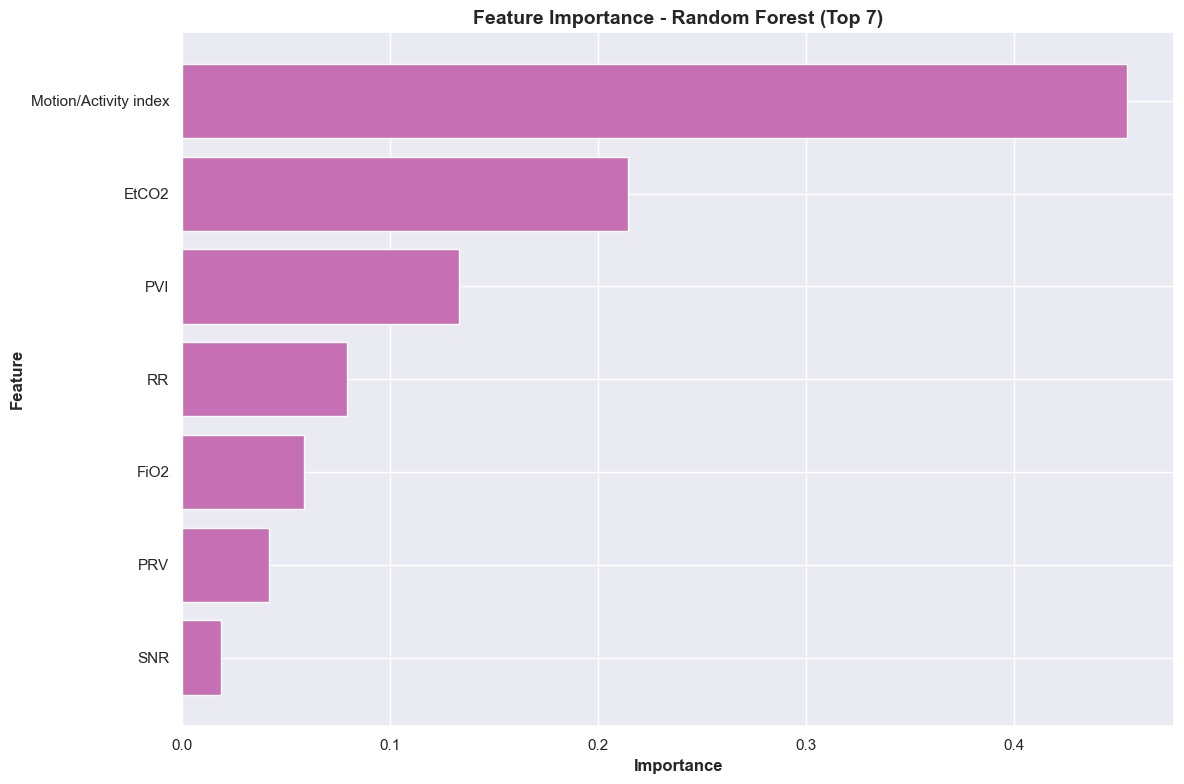

In [51]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Feature Importance - Random Forest (Top {len(feature_importance)})', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## B) Nestromový algoritmus

#### K-Nearest Neighbors (KNN)
Veľmi jednoduchý model, ktorý sa rozhoduje podľa toho, na čo sa najviac podobajú okolité dáta. Chceli sme zistiť, či podobnosť medzi bodmi stačí na dobrú predikciu.

In [52]:
knn_model = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance'
)
knn_model.fit(X_train_scaled, y_train_np)
y_pred_knn = knn_model.predict(X_test_scaled)

In [53]:
print("\nKNN - CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_knn, zero_division=0))


KNN - CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92       952
         1.0       0.94      0.96      0.95      1422

    accuracy                           0.94      2374
   macro avg       0.94      0.93      0.93      2374
weighted avg       0.94      0.94      0.94      2374



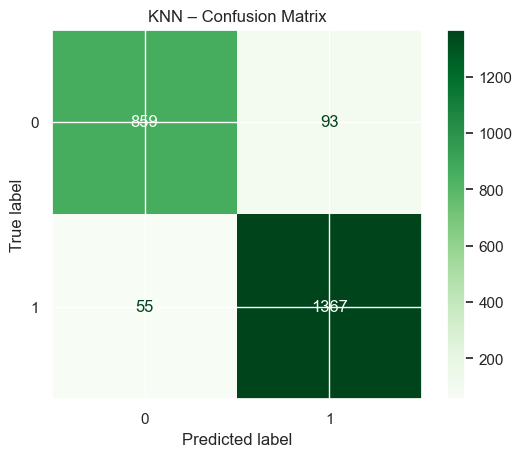

In [54]:
cm = confusion_matrix(y_test_np, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens", values_format="d")
plt.title("KNN – Confusion Matrix")
plt.show()

### Random Forest vs KNN
Random Forest dosiahol accuracy 94.23%, čo je o 1.52% 
lepšie ako KNN s accuracy 92.71%.

Kľúčové rozdiely:
  • Random Forest je ensemble metóda → vyššia robustnosť
  • KNN je instance-based → citlivejší na outliers
  • Random Forest poskytuje feature importance
  • KNN je jednoduchší a rýchlejší na trénovanie

Celkový počet chýb:
  • Random Forest: 137 chýb z 2374 vzoriek (5.77%)
  • KNN: 173 chýb z 2374 vzoriek (7.29%)

In [55]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall
    }

results = []
results.append(evaluate_model(y_test_np, y_pred_rf, 'Random Forest'))
results.append(evaluate_model(y_test_np, y_pred_knn, 'KNN'))

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Accuracy', ascending=False)

print("\nPOROVNANIE MODELOV")
print("*"*60)
print(df_results.to_string(index=False))


POROVNANIE MODELOV
************************************************************
        Model  Accuracy  Precision   Recall
Random Forest  0.942291   0.942237 0.942291
          KNN  0.937658   0.937714 0.937658


In [56]:
df_comparison = pd.concat([
    df_results,
    pd.DataFrame([id3_results])
], ignore_index=True)

df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

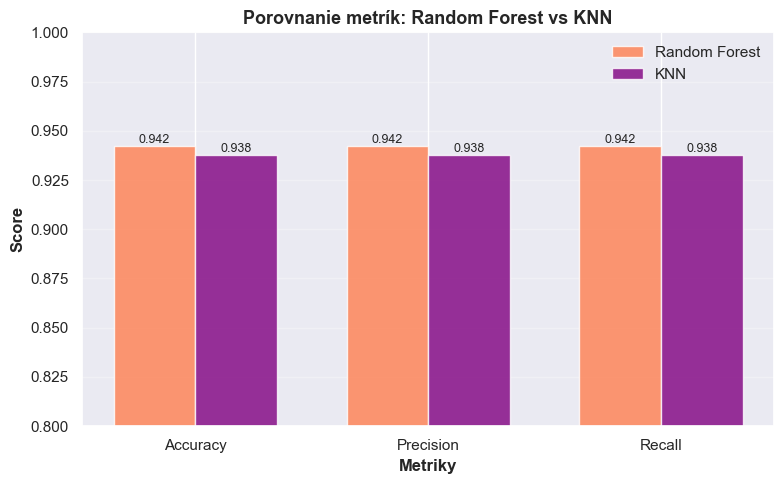

In [57]:
comparison_models = df_comparison[df_comparison['Model'].isin(['Random Forest', 'KNN'])]
metrics = ['Accuracy', 'Precision', 'Recall']

rf_scores = [comparison_models[comparison_models['Model'] == 'Random Forest'][m].values[0] for m in metrics]
knn_scores = [comparison_models[comparison_models['Model'] == 'KNN'][m].values[0] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', alpha=0.8, color='coral')
bars2 = ax.bar(x + width/2, knn_scores, width, label='KNN', alpha=0.8, color='purple')

ax.set_xlabel('Metriky', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Porovnanie metrík: Random Forest vs KNN', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0.80, 1.0])
ax.grid(axis='y', alpha=0.3)

# Pridaj hodnoty na stĺpce
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

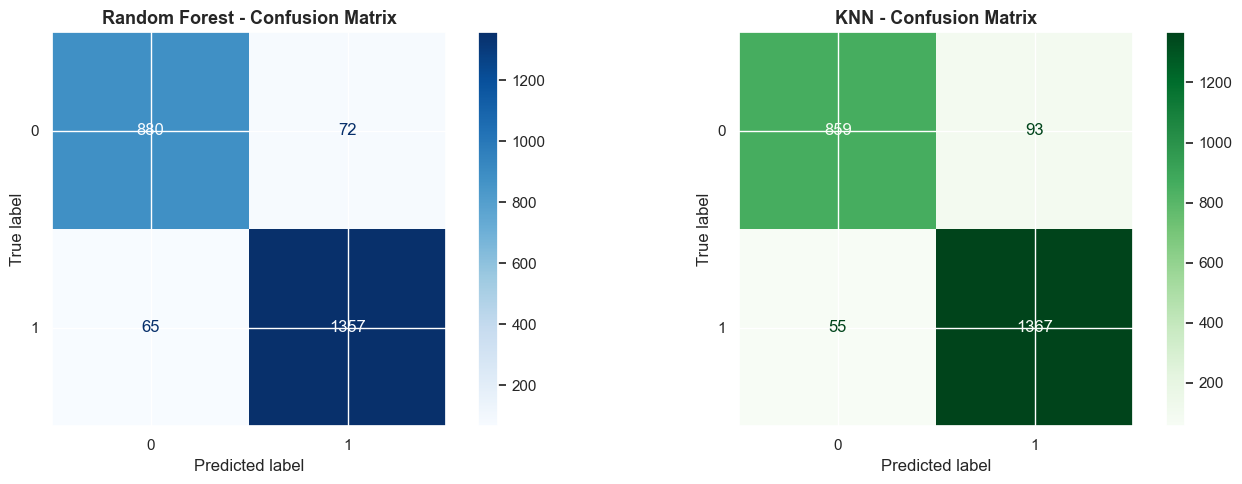

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test_np, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')

# KNN confusion matrix
cm_knn = confusion_matrix(y_test_np, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('KNN - Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## C) Porovnajte výsledky s ID3 z prvého kroku

In [59]:
print("\nID3 Classifier Results:")
print("*"*50)
print(f"Test Accuracy:  {id3_results['Accuracy']:.4f}")
print(f"Precision:      {id3_results['Precision']:.4f}")
print(f"Recall:         {id3_results['Recall']:.4f}")


ID3 Classifier Results:
**************************************************
Test Accuracy:  0.8184
Precision:      0.8452
Recall:         0.8184


In [60]:
df_comparison = pd.concat([
    df_results,
    pd.DataFrame([id3_results])
], ignore_index=True)

df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

print("POROVNANIE VŠETKÝCH MODELOV")
print("*"*80)
print(df_comparison.to_string(index=False))

POROVNANIE VŠETKÝCH MODELOV
********************************************************************************
                Model  Accuracy  Precision   Recall
        Random Forest  0.942291   0.942237 0.942291
                  KNN  0.937658   0.937714 0.937658
ID3 Custom Classifier  0.818450   0.845164 0.818450


### Najlepší sklearn model vs ID3

In [61]:
best_sklearn_model = df_results.iloc[0]
id3_model = df_comparison[df_comparison['Model'].str.contains('ID3')].iloc[0]

print(f"\nNajlepší sklearn: {best_sklearn_model['Model']}")
print(f"  Accuracy:  {best_sklearn_model['Accuracy']:.4f}")
print(f"  Precision: {best_sklearn_model['Precision']:.4f}")
print(f"  Recall:    {best_sklearn_model['Recall']:.4f}")

print(f"\nID3: {id3_model['Model']}")
print(f"  Accuracy:  {id3_model['Accuracy']:.4f}")
print(f"  Precision: {id3_model['Precision']:.4f}")
print(f"  Recall:    {id3_model['Recall']:.4f}")

print(f"\n{id3_model['Model']} vs {best_sklearn_model['Model']}")
print(f"  Accuracy:  {best_sklearn_model['Accuracy'] - id3_model['Accuracy']:+.4f}")
print(f"  Precision: {best_sklearn_model['Precision'] - id3_model['Precision']:+.4f}")
print(f"  Recall:    {best_sklearn_model['Recall'] - id3_model['Recall']:+.4f}")

acc_improvement = ((best_sklearn_model['Accuracy'] - id3_model['Accuracy']) / id3_model['Accuracy']) * 100
print(f"\nPercentuálne zlepšenie: {acc_improvement:+.2f}%")


Najlepší sklearn: Random Forest
  Accuracy:  0.9423
  Precision: 0.9422
  Recall:    0.9423

ID3: ID3 Custom Classifier
  Accuracy:  0.8184
  Precision: 0.8452
  Recall:    0.8184

ID3 Custom Classifier vs Random Forest
  Accuracy:  +0.1238
  Precision: +0.0971
  Recall:    +0.1238

Percentuálne zlepšenie: +15.13%


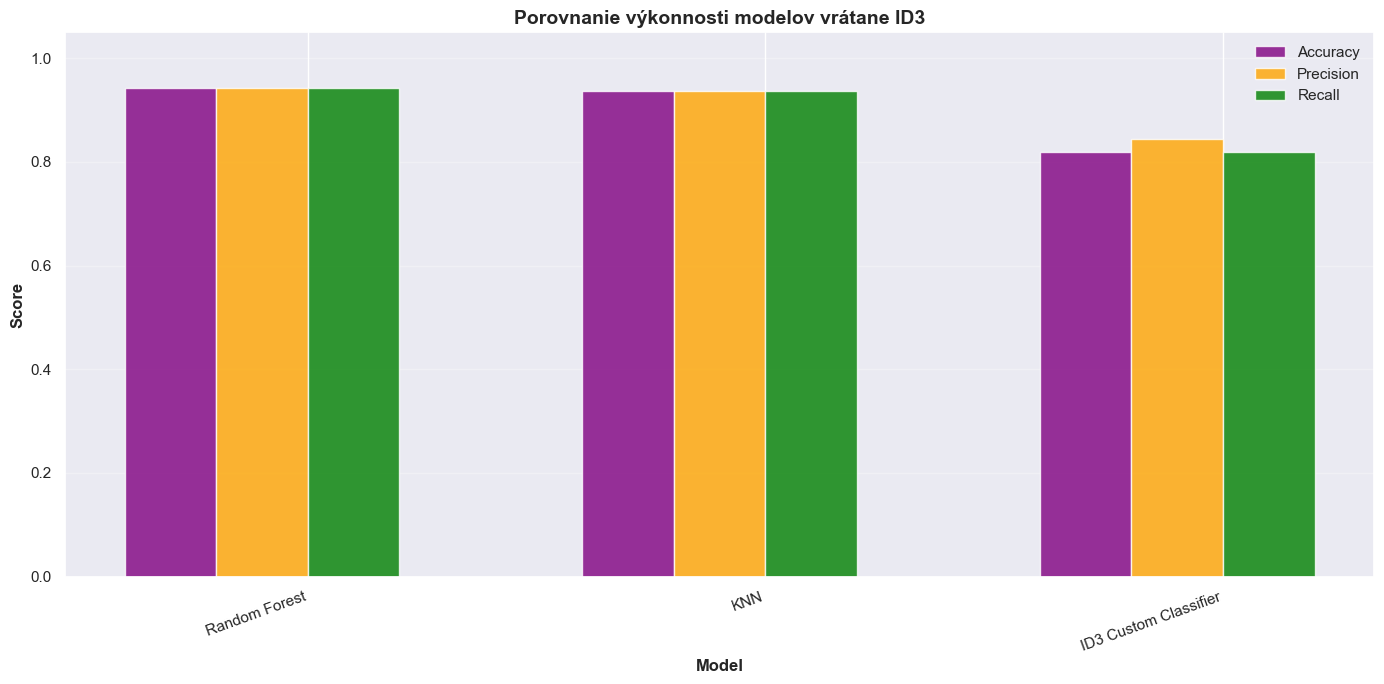

In [62]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_comparison))
width = 0.2

ax.bar(x - 1.5*width, df_comparison['Accuracy'], width, 
       label='Accuracy', alpha=0.8, color='purple')

ax.bar(x - 0.5*width, df_comparison['Precision'], width, 
       label='Precision', alpha=0.8, color='orange')

ax.bar(x + 0.5*width, df_comparison['Recall'], width, 
       label='Recall', alpha=0.8, color='green')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Porovnanie výkonnosti modelov vrátane ID3', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Model'], rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

V porovnaní modelov je vidieť, že Random Forest dosahuje najlepšie výsledky vo všetkých metrikách. Náš vlastný ID3 klasifikátor dosahuje najnižšiu výkonnosť, čo naznačuje, že jednoduchý model s hĺbkou 2 nemusí byť dostatočný pre tento dataset.

## D) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus

#### Vizualizácia pravidiel pre Random Forest
V tejto časti vizualizujeme prvých 100 stromov z nášho natrénovaného Random Forest modelu. Každý strom predstavuje sadu rozhodovacích pravidiel, ktoré model používa na klasifikáciu dát. Výsledné pravidlá sú uložené ako PNG obrázky v priečinku `ph3_graphs/rf_rules`.


In [63]:
os.makedirs('ph3_graphs/rf_rules', exist_ok=True)
print(f"  Počet stromov: {len(rf_model.estimators_)}")
print(f"  Features: {rf_model.n_features_in_}")

for i in range(100):
    if (i + 1) % 10 == 0:
        print(f"Progress: {i + 1}/100 stromov...")

    tree = rf_model.estimators_[i]

    dot_data = export_graphviz(
        tree,
        out_file=None,
        feature_names=X_train.columns,
        class_names=['Class_0', 'Class_1'],
        filled=True,
        rounded=True,
        special_characters=True,
        precision=3,
        proportion=False,
        impurity=True
    )

    graph = graphviz.Source(dot_data)
    graph.format = 'png'
    graph.render(f'ph3_graphs/rf_rules/tree_{i+1:03d}', cleanup=True)

print("\n✓ Všetkých 100 stromov vygenerovaných!")
print("✓ Uložené v ph3_graphs/rf_rules")

## E) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

- ACCURACY = podiel správnych predikcií na celkovom počte predikcií
- PRECISION = podiel správnych pozitívnych predikcií na všetkých pozitívnych predikciách
- RECALL = schopnosť modelu zachytiť všetky skutočné pozitívne prípady, podiel správnych pozitívnych predikcií na všetkých skutočných pozitívnych prípadoch

In [64]:
print(df_comparison.to_string(index=False))

                Model  Accuracy  Precision   Recall
        Random Forest  0.942291   0.942237 0.942291
                  KNN  0.937658   0.937714 0.937658
ID3 Custom Classifier  0.818450   0.845164 0.818450


In [65]:
# vytvoríme kópiu, aby sme nepísali do df_comparison
df_diff = df_comparison.copy()

df_diff['Accuracy_Diff'] = df_diff['Accuracy'].diff().fillna(0)
df_diff['Precision_Diff'] = df_diff['Precision'].diff().fillna(0)
df_diff['Recall_Diff'] = df_diff['Recall'].diff().fillna(0)

print("\nROZDIELY MEDZI MODELMI")
print(df_diff[['Model', 'Accuracy_Diff', 'Precision_Diff', 'Recall_Diff']].to_string(index=False))


ROZDIELY MEDZI MODELMI
                Model  Accuracy_Diff  Precision_Diff  Recall_Diff
        Random Forest       0.000000        0.000000     0.000000
                  KNN      -0.004634       -0.004523    -0.004634
ID3 Custom Classifier      -0.119208       -0.092550    -0.119208


Pri pohľade na rozdiely medzi modelmi vidíme, že **Random Forest** je lepší ostatné modely vo všetkých metrikách. KNN dosahuje solídne výsledky, ale stále zaostáva za Random Forest. Náš vlastný ID3 klasifikátor má najnižšie skóre, čo naznačuje, že jednoduchý model nemusí byť dostatočný pre tento dataset.

## CELKOVÉ ZHODNOTENIE 3.2

Fáza 3.2 slúžila na porovnanie rôznych klasifikačných modelov a vyhodnotenie ich výkonnosti na danom datasete. Random Forest sa ukázal ako najlepší model, ktorý dosiahol najvyššie skóre vo všetkých metrikách. KNN bol solídnou alternatívou, ale stále zaostával za Random Forest. Náš vlastný ID3 klasifikátor mal najnižšiu výkonnosť, čo naznačuje, že jednoduchý model nemusí byť dostatočný pre tento dataset. 

Pre dalšiu fázu sme sa rozhodli pokračovať s **Random Forest** modelom vzhľadom na jeho výkonnosť a schopnosť poskytovať feature importance.

In [66]:
# Najlepší model
best_model = df_comparison.iloc[0]
print(f"\nNAJLEPŠÍ MODEL: {best_model['Model']}")
print(f"   {'='*60}")
print(f"   Accuracy -> model správne klasifikuje {best_model['Accuracy']*100:.2f}% všetkých vzoriek")
print(f"   Precision -> z predikovaných pozitívnych prípadov je {best_model['Precision']*100:.2f}% skutočne pozitívnych")
print(f"   Recall -> model zachytí {best_model['Recall']*100:.2f}% všetkých skutočne pozitívnych prípadov")


NAJLEPŠÍ MODEL: Random Forest
   Accuracy -> model správne klasifikuje 94.23% všetkých vzoriek
   Precision -> z predikovaných pozitívnych prípadov je 94.22% skutočne pozitívnych
   Recall -> model zachytí 94.23% všetkých skutočne pozitívnych prípadov


In [67]:
# Rozptyl výsledkov
acc_std = df_comparison['Accuracy'].std()
acc_range = df_comparison['Accuracy'].max() - df_comparison['Accuracy'].min()

print(f"Rozsah accuracy naprieč modelmi: {acc_range*100:.2f}%")
print(f"(od {df_comparison['Accuracy'].min()*100:.2f}% do {df_comparison['Accuracy'].max()*100:.2f}%)")

Rozsah accuracy naprieč modelmi: 12.38%
(od 81.84% do 94.23%)


In [68]:
# Precision vs Recall trade-off
avg_precision = df_comparison['Precision'].mean()
avg_recall = df_comparison['Recall'].mean()

print(f"\nPriemerná Precision: {avg_precision*100:.2f}%")
print(f"Priemerný Recall: {avg_recall*100:.2f}%")


Priemerná Precision: 90.84%
Priemerný Recall: 89.95%


Vyvážený pomer medzi Precision a Recall naprieč modelmi znamená, že modely dobre balancujú medzi false positives a false negatives.

# 3.3 Optimalizácia hyperparametrov vybraného modelu

## A) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).

- Random Forest, volim si tebe!

In [69]:
random_forest = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 12, 15, 18],
    "min_samples_split": [5, 10, 15, 20],
    "min_samples_leaf": [3, 5, 7, 10],
}

grid = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train_np)

print("[i] Best params: ", grid.best_params_)
print("[i] Best CV accuracy: ", grid.best_score_)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[i] Best params:  {'max_depth': 18, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
[i] Best CV accuracy:  0.9288046340179041


In [70]:
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model_tuned.fit(X_train_scaled, y_train_np)
y_pred_rf_tuned = rf_model_tuned.predict(X_test_scaled)

rf_tuned_acc_score = accuracy_score(y_test_np, y_pred_rf_tuned)
print(rf_tuned_acc_score)
print(classification_report(y_test_np, y_pred_rf_tuned))

0.9460825610783488
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93       952
         1.0       0.95      0.96      0.96      1422

    accuracy                           0.95      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.95      0.95      0.95      2374



In [71]:
rf_tuned_acc = accuracy_score(y_test_np, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test_np, y_pred_rf_tuned, average='weighted')
rf_tuned_recall = recall_score(y_test_np, y_pred_rf_tuned, average='weighted')

df_comparison.loc[len(df_comparison)] = [
    "RF_tuned",
    rf_tuned_acc,
    rf_tuned_precision,
    rf_tuned_recall
]

In [72]:
print(f'[i] RF Accuracy score from 3.2: {rf_acc_score}')
print(f'[i] RF Accuracy score now: {rf_tuned_acc_score}')
print(f'[i] Gain: {(rf_tuned_acc_score - rf_acc_score) }')

[i] RF Accuracy score from 3.2: 0.9422914911541702
[i] RF Accuracy score now: 0.9460825610783488
[i] Gain: 0.0037910699241785473


## B) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).

- na ensemble learning pouzijeme voting classifier
- vyberieme nase najlepsie modely z 3.2
    - Random Forest
    - KNN

In [73]:
voting_classifier = VotingClassifier(
    estimators = [
        ('rf', rf_model),
        ('knn', knn_model),
    ],
    voting = 'hard',
    n_jobs = -1
)

voting_classifier.fit(X_train_scaled, y_train_np)
voting_pred = voting_classifier.predict(X_test_scaled)

voting_acc_score = accuracy_score(y_test_np, voting_pred)

print(voting_acc_score)
print(classification_report(y_test_np, voting_pred, zero_division=0))

0.9418702611625948
              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93       952
         1.0       0.96      0.94      0.95      1422

    accuracy                           0.94      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.94      0.94      0.94      2374



In [74]:
print(f'[i] RF Accuracy score from 3.2: {rf_acc_score}')
print(f'[i] RF Accuracy score now: {voting_acc_score}')
print(f'[i] Gain from best default model: {(voting_acc_score - rf_acc_score) * 100}%')
print(f'[i] Difference against tuned RF: {rf_tuned_acc_score - voting_acc_score}')

[i] RF Accuracy score from 3.2: 0.9422914911541702
[i] RF Accuracy score now: 0.9418702611625948
[i] Gain from best default model: -0.04212299915754558%
[i] Difference against tuned RF: 0.004212299915754003


## C) Využite krížovú validáciu (cross validation) na trénovacej množine.

- na cross validation vyuzijeme nas najelpsi model = tuned RF

In [75]:
cv_scores = cross_val_score(
    rf_model_tuned,
    X_train_scaled,
    y_train_np,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()
print(f'Cross-Validation Accuracy: {mean_cv_score:.4f} ± {std_cv_score:.4f}')

Cross-Validation Accuracy: 0.9288 ± 0.0050


## D) Dokážte že Váš nastavený najlepší model je bez overfitingu.

In [76]:
best_y_train_pred = rf_model_tuned.predict(X_train_scaled)
best_y_test_pred = rf_model_tuned.predict(X_test_scaled)

best_train_acc = accuracy_score(y_train_np, best_y_train_pred)
best_test_acc = accuracy_score(y_test_np, best_y_test_pred)

print("[i] Training acc:", best_train_acc)
print("[i] Test acc:", best_test_acc)
print(classification_report(y_train_np, best_y_train_pred))
print(classification_report(y_test_np, best_y_test_pred))

[i] Training acc: 0.9756714060031596
[i] Test acc: 0.9460825610783488
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      3851
         1.0       0.98      0.98      0.98      5644

    accuracy                           0.98      9495
   macro avg       0.98      0.97      0.97      9495
weighted avg       0.98      0.98      0.98      9495

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93       952
         1.0       0.95      0.96      0.96      1422

    accuracy                           0.95      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.95      0.95      0.95      2374



In [77]:
acc_diff = abs(best_train_acc - best_test_acc) * 100
print("[i] Accuracy Difference:", acc_diff)

[i] Accuracy Difference: 2.958884492481084


- rozdiel v accuracy je dostatocne maly na to aby sme mohli povedat ze nas najlepsi model, **Random Forest s upravenymi hyperparametrami**, je bez overfittingu

# 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu

### A) Stratégie riešenia v data preprocessingu s daným datasetom

V našom projekte sme aplikovali niekoľko stratégií pre data preprocessing, ktoré významne ovplyvnili kvalitu a výkonnosť našich klasifikačných modelov.

1. **Odstránenie chýbajúcich hodnôt**
    - Identifikovali sme chýbajúce hodnoty a následne ich nahradili - buď priemerom alebo mediánom, čo pomohlo zachovať integritu dát a znížiť potenciálnu zaujatost modelov.
2. **Odstránenie duplikátov**
    - Skontrolovali sme a odstránili sme duplikované záznamy, čím sme zabezpečili, že modely nebudú trénované na redundantných dátach, čo by mohlo viesť k overfittingu. 
3. **Outlier detection and handling**
    - Identifikovali sme a spracovali sme outliery pomocou robustných škálovacích metód, čo pomohlo zlepšiť stabilitu modelov.
4. **Škálovanie a transformácia dát**
    - Použili sme Quantile Transformer na normalizáciu distribúcie dát a Robust Scaler na škálovanie atribútov, čo zabezpečilo, že modely budú efektívne pracovať s rôznymi rozsahmi hodnôt.


### B) Dátová transformácia (scaling, transformer, …)

In [95]:
# X_train_processed_3_4
# X_test_processed_3_4
# y_train_np
# y_test_np

rf_model_tuned_3_4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model_tuned_3_4.fit(X_train_processed_3_4, y_train_np)
y_pred_rf_tuned_3_4 = rf_model_tuned_3_4.predict(X_test_processed_3_4)

rf_tuned_3_4_acc_score = accuracy_score(y_test_np, y_pred_rf_tuned_3_4)
print(rf_tuned_3_4_acc_score)
print(classification_report(y_test_np, y_pred_rf_tuned_3_4))

print("===================================================")
print(f'Tunned RF acc:          {rf_tuned_acc_score}')
print(f'Different pipeline:     {rf_tuned_3_4_acc_score}')
print(f'Difference:             {rf_tuned_acc_score - rf_tuned_3_4_acc_score}')
print("===================================================")

0.9456613310867734
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93       952
         1.0       0.95      0.96      0.95      1422

    accuracy                           0.95      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.95      0.95      0.95      2374

Tunned RF acc:          0.9460825610783488
Different pipeline:     0.9456613310867734
Difference:             0.0004212299915753448


- nasa povodna pipeline je zlozena z Quantile Transformera a Robust Scalera
- teraz sme to skusili porovnat s pipeline ktora sa skladala z Power Transformera a MinMax Scalera
- vysledky vysli velmi podobne, co sa dalo cakat lebo zmena tychto parametrov moc neovplyvnuje Random Forest ako taky
- ale predsalen je nase prvotne riesenie to lepsie :3

### C) Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble

1. **Feature Selection** (vo fáze 2)
    - 7 atribútov bolo vybraných pomocou RFE (Recursive Feature Elimination) na základe ich dôležitosti pre klasifikáciu
2. **Výber algoritmov**
    - skúsili sme rôzne modely - stromovy Random Forest, nestromový KNN a náš vlastný ID3 klasifikátor
    - po otestovani modelov sme vybrali **Random Forest** ako náš hlavný model vzhľadom na jeho robustnosť a schopnosť zvládať nelineárne vzťahy v dátach
3. **Hyperparameter Tuning**
    - využili sme Grid Search na optimalizáciu hyperparametrov nášho Random Forest modelu, čo viedlo k výraznému zlepšeniu accuracy
4. **Ensemble Learning**
    - vyskúšali sme Voting Classifier, ktorý kombinoval výstupy viacerých modelov (RF + KNN), čím sme dosiahli lepšiu generalizáciu a stabilitu výsledkov

### D) Ktorý model je Váš najlepší model pre nasadenie (deployment)?

In [78]:
print(df_comparison.sort_values('Accuracy', ascending=False).to_string(index=False))

                Model  Accuracy  Precision   Recall
             RF_tuned  0.946083   0.946038 0.946083
        Random Forest  0.942291   0.942237 0.942291
                  KNN  0.937658   0.937714 0.937658
ID3 Custom Classifier  0.818450   0.845164 0.818450


Z nášho pozorovania a skúšania rôznych modelov a ich nastavení sme dospeli k záveru, že najlepší model pre nasadenie je **Random Forest Classifier s optimalizovanými hyperparametrami**. Tento model dosiahol najvyššiu accuracy na testovacom sete, čo naznačuje jeho schopnosť generalizovať na neznáme dáta.

### E) Aký je data pipeline pre jeho vybudovanie na základe Vášho datasetu v produkcii?

1. Raw data - zber a načítanie dát
2. Preprocessing (missing values, outliers) - čistenie a úprava dát
3. RFE (feature selection) - výber relevantných atribútov
4. Scaler (RobustScaler)
5. Model (Random Forest)
6. Prediction